<a href="https://colab.research.google.com/github/AliHazem3/AirPlane/blob/main/AirPlane_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 905.3/905.3 kB 44.7 MB/s eta 0:00:00


In [ ]:
train_images_path = '/content/drive/MyDrive/AirBus Detection/train/images'
train_labels_path = '/content/drive/MyDrive/AirBus Detection/train/labels'
val_images_path = '/content/drive/MyDrive/AirBus Detection/valid/images'
val_labels_path = '/content/drive/MyDrive/AirBus Detection/valid/labels'

In [ ]:
import os

# Paths to training images and labels
train_images_path = '/content/drive/MyDrive/AirBus Detection/train/images'
train_labels_path = '/content/drive/MyDrive/AirBus Detection/train/labels'

# Count the number of image files
image_files = [file for file in os.listdir(train_images_path) if file.endswith(('.jpg', '.jpeg'))]

# Count the number of label files
label_files = [file for file in os.listdir(train_labels_path) if file.endswith('.txt')]

# Check how many labels correspond to images (assuming the same base filenames)
image_base_names = set(os.path.splitext(file)[0] for file in image_files)
label_base_names = set(os.path.splitext(file)[0] for file in label_files)
matched_labels = image_base_names.intersection(label_base_names)

print(f"Number of training images: {len(image_files)}")
print(f"Number of label files: {len(label_files)}")
print(f"Number of matched image-label pairs: {len(matched_labels)}")

# Warn about mismatched files
unmatched_images = image_base_names - label_base_names
unmatched_labels = label_base_names - image_base_names

if unmatched_images:
    print(f"Warning: {len(unmatched_images)} images have no corresponding label.")
if unmatched_labels:
    print(f"Warning: {len(unmatched_labels)} labels have no corresponding image.")


Number of training images: 700
Number of label files: 700
Number of matched image-label pairs: 700


In [ ]:
import os

# Paths to training images and labels
val_images_path = '/content/drive/MyDrive/AirBus Detection/valid/images'
val_labels_path = '/content/drive/MyDrive/AirBus Detection/valid/labels'

# Count the number of image files
image_files = [file for file in os.listdir(train_images_path) if file.endswith(('.jpg', '.jpeg'))]

# Count the number of label files
label_files = [file for file in os.listdir(train_labels_path) if file.endswith('.txt')]

# Check how many labels correspond to images (assuming the same base filenames)
image_base_names = set(os.path.splitext(file)[0] for file in image_files)
label_base_names = set(os.path.splitext(file)[0] for file in label_files)
matched_labels = image_base_names.intersection(label_base_names)

print(f"Number of validation images: {len(image_files)}")
print(f"Number of label files: {len(label_files)}")
print(f"Number of matched image-label pairs: {len(matched_labels)}")

# Warn about mismatched files
unmatched_images = image_base_names - label_base_names
unmatched_labels = label_base_names - image_base_names

if unmatched_images:
    print(f"Warning: {len(unmatched_images)} images have no corresponding label.")
if unmatched_labels:
    print(f"Warning: {len(unmatched_labels)} labels have no corresponding image.")


Number of validation images: 700
Number of label files: 700
Number of matched image-label pairs: 700


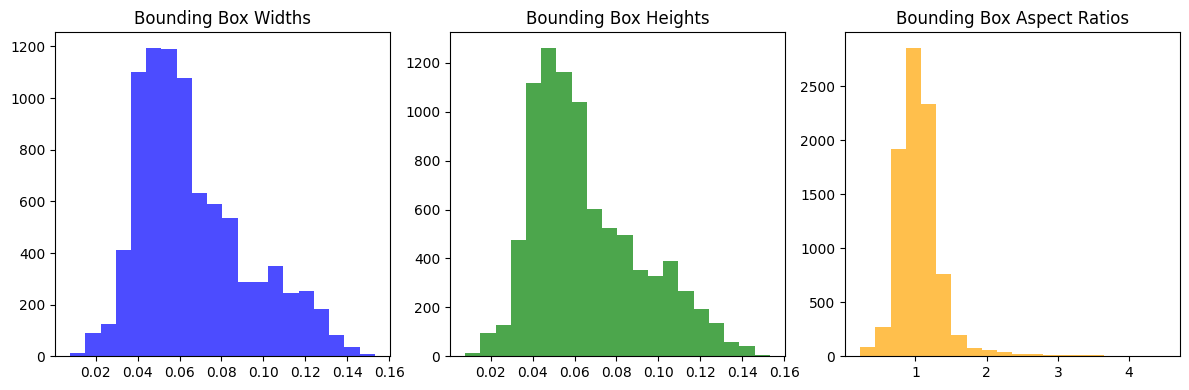

In [ ]:
import matplotlib.pyplot as plt

# Initialize lists to store bounding box stats
widths = []
heights = []
aspect_ratios = []
annotations_path = '/content/drive/MyDrive/AirBus Detection/train/labels'
# Loop through annotation files
for file_name in os.listdir(annotations_path):
    if file_name.endswith('.txt'):
        with open(os.path.join(annotations_path, file_name), 'r') as file:
            for line in file:
                _, x_center, y_center, width, height = map(float, line.split())
                widths.append(width)
                heights.append(height)
                aspect_ratios.append(width / height)

# Plot histograms
plt.figure(figsize=(12, 4))

# Widths
plt.subplot(1, 3, 1)
plt.hist(widths, bins=20, color='blue', alpha=0.7)
plt.title('Bounding Box Widths')

# Heights
plt.subplot(1, 3, 2)
plt.hist(heights, bins=20, color='green', alpha=0.7)
plt.title('Bounding Box Heights')

# Aspect Ratios
plt.subplot(1, 3, 3)
plt.hist(aspect_ratios, bins=20, color='orange', alpha=0.7)
plt.title('Bounding Box Aspect Ratios')

plt.tight_layout()
plt.show()

In [ ]:
import os
print("Train images path:", os.listdir(train_images_path)[:5])  # List some of the images in the train folder
print("Validation images path:", os.listdir(val_images_path)[:5])  # List some of the images in the validation folder

# Create the YAML configuration file for YOLOv8
dataset_yaml = """
train: /content/drive/MyDrive/AirBus Detection/train/images
val: /content/drive/MyDrive/AirBus Detection/valid/images

nc: 1  # Number of classes (airplane)
names: ['airplane']  # Class names
"""

Train images path: ['4a0821b7-3689-4b0e-9397-389254ea9a32_0_0_jpg.rf.90719ca2a2b17dff7a250375a3d5b7b1.jpg', '014de911-7810-4f7d-8967-3e5402209f4a_0_0_jpg.rf.77e233628eec19d0fa0cc4a57a977fce.jpg', '495b73c8-024f-46cc-b426-05e49bbe5074_0_0_jpg.rf.6bb5aef4518d8efa2c7c65cffea4fb37.jpg', '54442e49-5271-42bf-a8fb-a2cab30cfd49_1060_1060_jpg.rf.ca9de8ae931f8c0f23ef1f4f9c3ba7e3.jpg', '140d04fd-dea7-4d46-bce2-e20f73e155da_1060_1060_jpg.rf.3e21f10a45363bf32ea15714d569ba44.jpg']
Validation images path: ['996ba764-cd2a-49c0-9c9f-b166207de0ab_0_0_jpg.rf.44f606b55b5f98b42148dc4879e6023a.jpg', '135fdc4c-6656-4176-9873-9f00c6918293_1060_1060_jpg.rf.5289e2ba3eeb6e5bdfe6bce83931e253.jpg', '03f84930-e2be-4c19-9afc-0dc26d02538e_1060_1060_jpg.rf.e182dcac2b8472f28ec0e8053c849733.jpg', '140d04fd-dea7-4d46-bce2-e20f73e155da_0_0_jpg.rf.5105f6550f279399dfd08a768754b0bc.jpg', 'cc4f3226-c262-409e-a4b2-a576e776f7f4_0_1060_jpg.rf.b5c3cc2ad70356249b3ea0d5532cb3d6.jpg']


In [ ]:
import os
print("Train images path:", os.listdir(train_images_path)[:5])  # List some of the images in the train folder
print("Validation images path:", os.listdir(val_images_path)[:5])  # List some of the images in the validation folder

# Create the YAML configuration file for YOLOv8
dataset_yaml = """
train: /content/drive/MyDrive/AirBus Detection/train/images
val: /content/drive/MyDrive/AirBus Detection/valid/images

nc: 1  # Number of classes (airplane)
names: ['airplane']  # Class names
"""

Train images path: ['4a0821b7-3689-4b0e-9397-389254ea9a32_0_0_jpg.rf.90719ca2a2b17dff7a250375a3d5b7b1.jpg', '014de911-7810-4f7d-8967-3e5402209f4a_0_0_jpg.rf.77e233628eec19d0fa0cc4a57a977fce.jpg', '495b73c8-024f-46cc-b426-05e49bbe5074_0_0_jpg.rf.6bb5aef4518d8efa2c7c65cffea4fb37.jpg', '54442e49-5271-42bf-a8fb-a2cab30cfd49_1060_1060_jpg.rf.ca9de8ae931f8c0f23ef1f4f9c3ba7e3.jpg', '140d04fd-dea7-4d46-bce2-e20f73e155da_1060_1060_jpg.rf.3e21f10a45363bf32ea15714d569ba44.jpg']
Validation images path: ['996ba764-cd2a-49c0-9c9f-b166207de0ab_0_0_jpg.rf.44f606b55b5f98b42148dc4879e6023a.jpg', '135fdc4c-6656-4176-9873-9f00c6918293_1060_1060_jpg.rf.5289e2ba3eeb6e5bdfe6bce83931e253.jpg', '03f84930-e2be-4c19-9afc-0dc26d02538e_1060_1060_jpg.rf.e182dcac2b8472f28ec0e8053c849733.jpg', '140d04fd-dea7-4d46-bce2-e20f73e155da_0_0_jpg.rf.5105f6550f279399dfd08a768754b0bc.jpg', 'cc4f3226-c262-409e-a4b2-a576e776f7f4_0_1060_jpg.rf.b5c3cc2ad70356249b3ea0d5532cb3d6.jpg']


In [ ]:
from ultralytics import YOLO
# Save the YAML configuration file to Google Drive

yaml_path = '/content/drive/MyDrive/AirBus Detection/airplane_dataset.yaml'
with open(yaml_path, 'w') as f:
    f.write(dataset_yaml)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
# Load pre-trained YOLOv8 model (you can choose 'yolov8n.pt', 'yolov8s.pt', etc.)
model = YOLO('yolov8n.pt')  # You can use different versions, e.g., yolov8s, yolov8m

100%|██████████| 6.25M/6.25M [00:00<00:00, 324MB/s]


In [ ]:
# Train the model using the dataset (specify the path to the YAML config file)
model.train(data=yaml_path, epochs=50, batch=16, imgsz=640)


Ultralytics 8.3.39 🚀 Python-3.10.12 torch-2.5.1+cpu CPU (Intel Xeon 2.00GHz)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/content/drive/MyDrive/AirBus Detection/airplane_dataset.yaml, epochs=50, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=Tr

100%|██████████| 755k/755k [00:00<00:00, 14.7MB/s]


Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytics

train: Scanning /content/drive/MyDrive/AirBus Detection/train/labels.cache... 700 images, 0 backgrounds, 0 corrupt: 100%|██████████| 700/700 [00:00<?, ?it/s]
val: Scanning /content/drive/MyDrive/AirBus Detection/valid/labels.cache... 149 images, 0 backgrounds, 0 corrupt: 100%|██████████| 149/149 [00:00<?, ?it/s]


Plotting labels to runs/detect/train/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.002, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
TensorBoard: model graph visualization added ✅
Image sizes 640 train, 640 val
Using 0 dataloader workers
Logging results to runs/detect/train
Starting training for 50 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

                   all        149       1957      0.968      0.943      0.954      0.694



50 epochs completed in 2.523 hours.
Optimizer stripped from runs/detect/train/weights/last.pt, 6.2MB
Optimizer stripped from runs/detect/train/weights/best.pt, 6.2MB

Validating runs/detect/train/weights/best.pt...
Ultralytics 8.3.39 🚀 Python-3.10.12 torch-2.5.1+cpu CPU (Intel Xeon 2.00GHz)
Model summary (fused): 168 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 5/5 [00:12<00:00,  2.59s/it]


                   all        149       1957      0.968      0.945      0.955      0.695
Speed: 0.9ms preprocess, 64.6ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to runs/detect/train


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7a53149cfee0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [ ]:
model_save_path = '/content/drive/MyDrive/models/yolov8_model.pt'

In [ ]:
model = YOLO(model_save_path)
# Confirm that the model has been loaded
print(f"Model loaded from: {model_save_path}")

Model loaded from: /content/drive/MyDrive/models/yolov8_model.pt


In [ ]:
# Evaluate the model after training (optional)
results = model.val()
print("Validation Results:")
print(results)

Ultralytics 8.3.57 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15102MiB)

Dataset 'coco.yaml' images not found ⚠️, missing path '/content/datasets/coco/val2017.txt'


100%|██████████| 169M/169M [00:05<00:00, 30.8MB/s]
Unzipping /content/datasets/coco2017labels-segments.zip to /content/datasets/coco...: 100%|██████████| 122232/122232 [00:22<00:00, 5537.69file/s]

Dataset download success ✅ (1481.8s), saved to /content/datasets



100%|██████████| 755k/755k [00:00<00:00, 90.3MB/s]
val: Scanning /content/datasets/coco/labels/val2017... 4952 images, 48 backgrounds, 0 corrupt: 100%|██████████| 5000/5000 [00:16<00:00, 300.97it/s]


val: New cache created: /content/datasets/coco/labels/val2017.cache


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95):   0%|          | 0/313 [00:02<?, ?it/s]


IndexError: index 22 is out of bounds for axis 1 with size 2


image 1/1 /content/drive/MyDrive/AirBus Detection/test/images/014de911-7810-4f7d-8967-3e5402209f4a_1060_0_jpg.rf.387550d1c7773e2df29177609a015210.jpg: 640x640 18 airplanes, 7.4ms
Speed: 7.4ms preprocess, 7.4ms inference, 823.3ms postprocess per image at shape (1, 3, 640, 640)


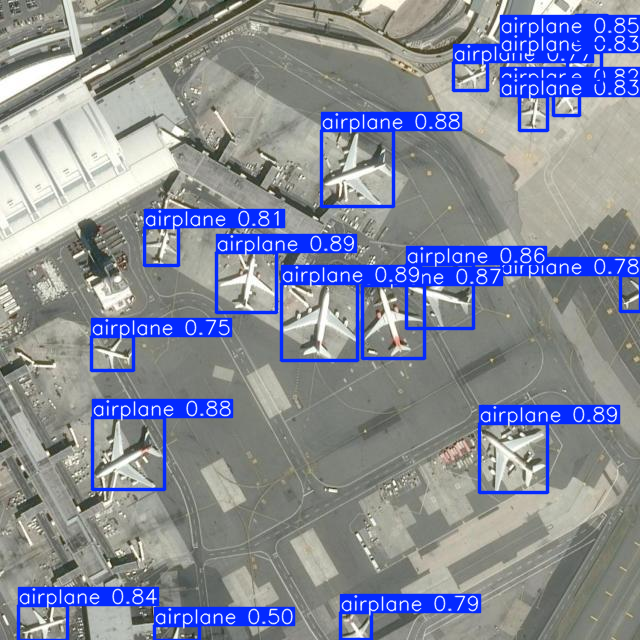

In [ ]:
image_path = '/content/drive/MyDrive/AirBus Detection/test/images/014de911-7810-4f7d-8967-3e5402209f4a_1060_0_jpg.rf.387550d1c7773e2df29177609a015210.jpg'
results = model(image_path)
results[0].show()

In [ ]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from google.colab.patches import cv2_imshow

# Load the large image
img_path = '/content/drive/MyDrive/Cairo_Airport_2.tif'
img = cv2.imread(img_path)

patch_size = 2048
height, width, _ = img.shape

# Initialize an empty list to store image arrays
image_patches = []

# Process image in patches
for y in range(0, height, patch_size):
    row_patches = []
    for x in range(0, width, patch_size):
        patch = img[y:min(y + patch_size, height), x:min(x + patch_size, width)]
        results = model(patch)

        # Convert result[0].show() output to an image array
        patch_result_img = results[0].plot()  # This returns the image with detections as an array

        row_patches.append(patch_result_img)

    # Append the row of patches to the list
    image_patches.append(row_patches)

# Now, combine all patches vertically and horizontally
# First, combine each row horizontally (side by side)
combined_rows = [np.hstack(row) for row in image_patches]

# Then, combine all rows vertically (top to bottom)
final_image = np.vstack(combined_rows)

# Show the reconstructed full image
cv2_imshow(final_image)

# Save the final reconstructed image
cv2.imwrite('/content/drive/MyDrive/AAoutput_full_image.jpg', final_image)


0: 640x640 (no detections), 905.3ms
Speed: 24.0ms preprocess, 905.3ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 874.7ms
Speed: 19.5ms preprocess, 874.7ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 1108.7ms
Speed: 39.7ms preprocess, 1108.7ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 airplane, 354.9ms
Speed: 9.8ms preprocess, 354.9ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 312.9ms
Speed: 10.6ms preprocess, 312.9ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 airplane, 213.1ms
Speed: 8.7ms preprocess, 213.1ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 7 airplanes, 215.5ms
Speed: 9.2ms preprocess, 215.5ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 8 airplanes, 210.9ms
Speed: 10.5ms preprocess, 210.